Importing Libraries

In [585]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Read DataSet Healthcare

In [586]:
df = pd.read_csv('healthcare_dataset.csv')

Exploring the Dataset

In [587]:
#Shape and Display 10 rows
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Shape: 6000 rows × 7 columns


,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0
5,6,31,28.3,3.2,0,117.2,1
6,7,21,27.4,3.7,0,116.7,0
7,8,76,27.0,1.8,1,151.4,0
8,9,53,22.0,1.4,1,131.6,0
9,10,67,21.7,2.8,0,125.5,0


In [588]:
# Column types
print("Column Data Types:")
print(df.dtypes)

# c. Missing values
print("Missing Values per Column:")
missing = df.isnull().sum()
print(missing)
print(f"Total missing values: {missing.sum()}")

Column Data Types:
patient_id                   int64
age                          int64
bmi                        float64
exercise_hours_per_week    float64
smoker                       int64
blood_pressure             float64
diabetes                     int64
dtype: object
Missing Values per Column:
patient_id                 0
age                        0
bmi                        0
exercise_hours_per_week    0
smoker                     0
blood_pressure             0
diabetes                   0
dtype: int64
Total missing values: 0


Statistical Analysis

In [589]:
df.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


In [590]:
counts = df['diabetes'].value_counts()
per    = df['diabetes'].value_counts(normalize=True) * 100
dist   = pd.DataFrame({'Count': counts, 'Percentage%': per.round(2)})
dist.index = ['No Diabetes (0)', 'Diabetes (1)']
print(dist)

                 Count  Percentage%
No Diabetes (0)   5458        90.97
Diabetes (1)       542         9.03


Visualaization


In [591]:
#importing neccesary libaries for visual
import matplotlib.pyplot as plt
import seaborn as sns

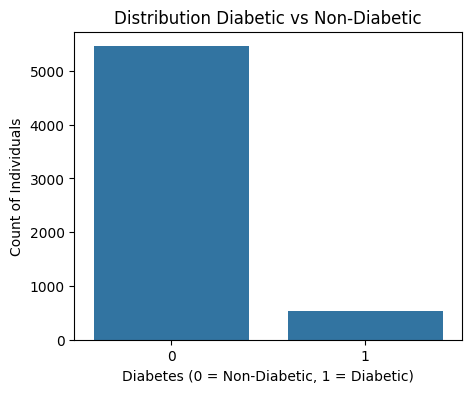

In [592]:
#Diabetic and non diabetic distribution count
plt.figure(figsize=(5,4))
sns.countplot(x='diabetes', data=df)
plt.title('Distribution Diabetic vs Non-Diabetic')
plt.xlabel('Diabetes (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count of Individuals')
plt.show()

- Most people are non-diabetic (0)
- Very few people are diabetic (1)
- Data is imbalanced (unequal classes)

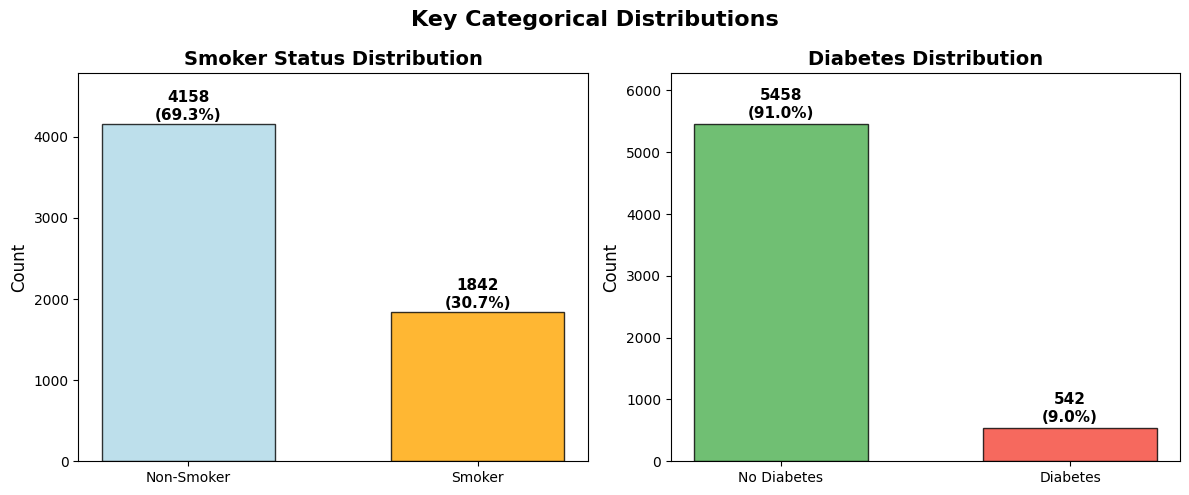

In [593]:
# Smoker and Diabetes Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Key Categorical Distributions', fontsize=16, fontweight='bold')

# Smoker distribution
smoker_counts = df['smoker'].value_counts()
axes[0].bar(['Non-Smoker', 'Smoker'], smoker_counts.values,
            color=['lightblue', 'orange'], edgecolor='black', alpha=0.8, width=0.6)
axes[0].set_title('Smoker Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_ylim(0, max(smoker_counts.values) * 1.15)
for i, v in enumerate(smoker_counts.values):
    axes[0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)

# Diabetes distribution
diabetes_counts = df['diabetes'].value_counts()
axes[1].bar(['No Diabetes', 'Diabetes'], diabetes_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='black', alpha=0.8, width=0.6)
axes[1].set_title('Diabetes Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_ylim(0, max(diabetes_counts.values) * 1.15)
for i, v in enumerate(diabetes_counts.values):
    axes[1].text(i, v + 100, f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

- Most people are non-smokers (69.3%)
- Majority have no diabetes (91%)
- Diabetes cases are very low compared to non-diabetes
- There are more non-smokers than smokers

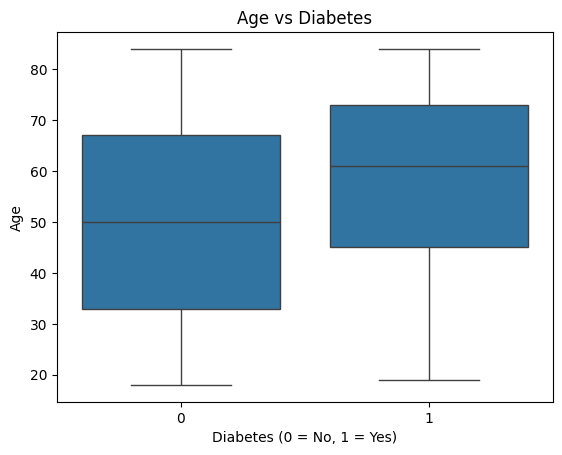

In [594]:
sns.boxplot(x='diabetes', y='age', data=df)
plt.title('Age vs Diabetes')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

#Insights
- Diabetic patients are generally older than non-diabetic patients.
- Median age is higher for diabetics.
-younger patients can have diabetes, the probability increases with age.

<Figure size 800x500 with 0 Axes>

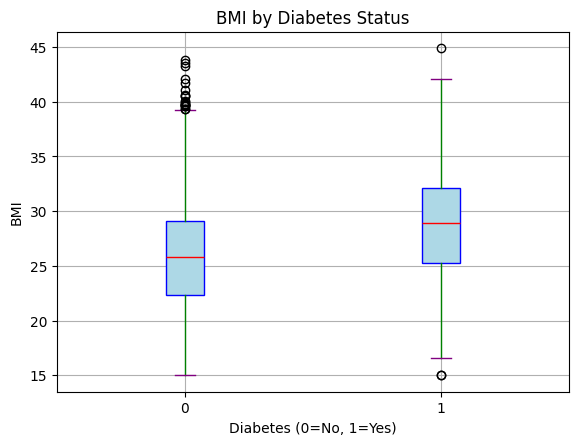

In [595]:
plt.figure(figsize=(8, 5))
df.boxplot(
    column='bmi',
    by='diabetes',
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='blue'),
    medianprops=dict(color='red'),
    whiskerprops=dict(color='green'),
    capprops=dict(color='purple')
)
plt.title('BMI by Diabetes Status')
plt.suptitle('')
plt.xlabel('Diabetes (0=No, 1=Yes)')
plt.ylabel('BMI')

plt.show()

- Diabetic patients generally have a higher BMI than non-diabetic patients.
- Most diabetics fall in the overweight or obese category, indicating that BMI is a strong predictor of diabetes risk.
- Increasing BMI correlates positively with diabetes prevalence.

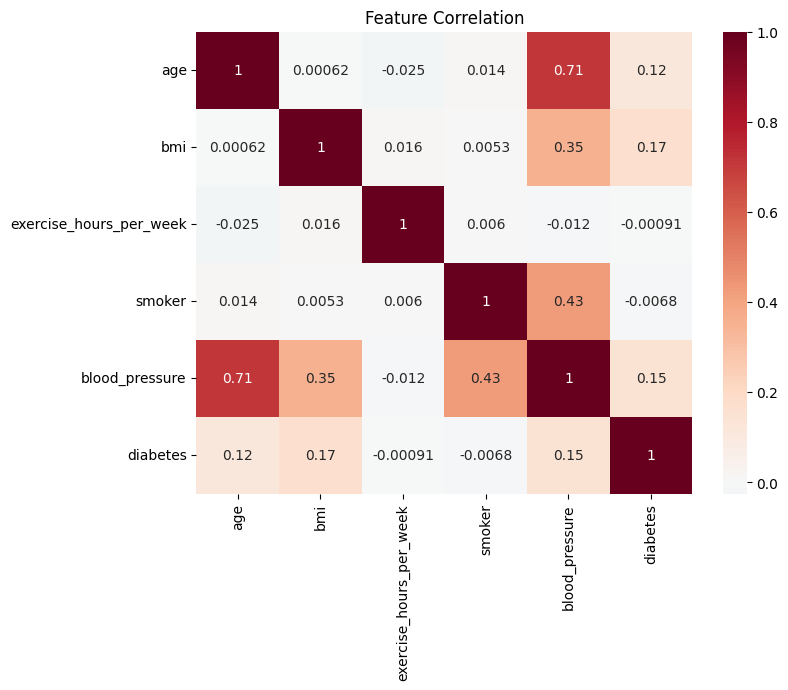

In [596]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
features = ['age', 'bmi', 'exercise_hours_per_week', 'smoker', 'blood_pressure', 'diabetes']
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation')
plt.show()

- The correlation heatmap shows that diabetes has weak positive correlations with BMI, age, and blood pressure, while exercise and smoking have almost no direct correlation.
- Age and blood pressure are strongly correlated with each other, and BMI is moderately correlated with blood pressure.
- Age and blood pressure are strongly related (0.71)
- Smoker and blood pressure have moderate relation (0.43)
- BMI has a moderate link with blood pressure (0.35)


Data Pre Processing

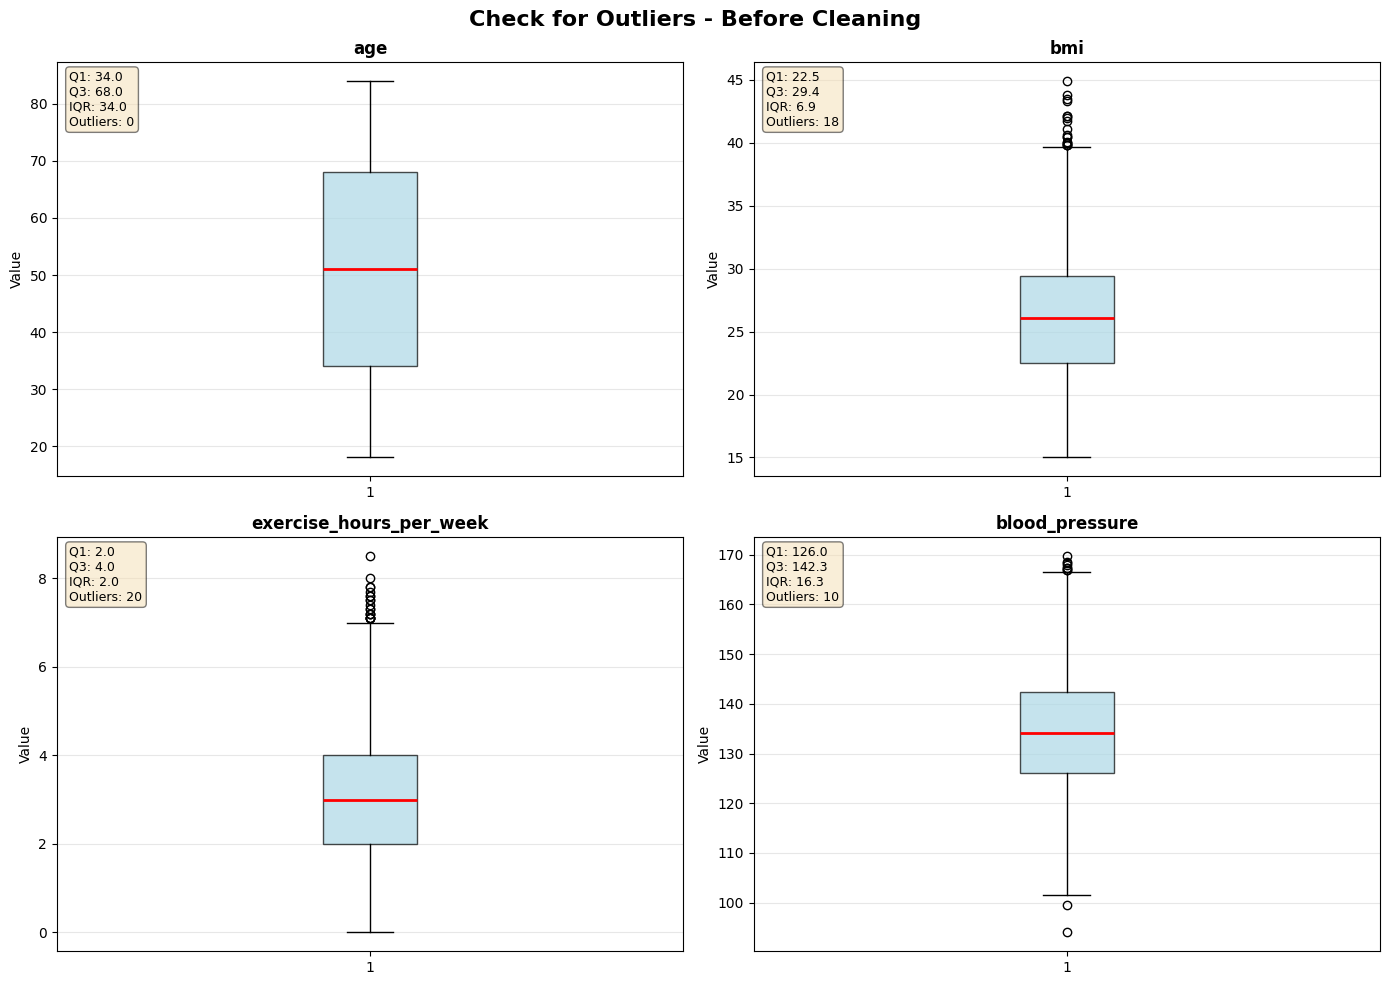

Outlier counts per feature:
  age: 0 outliers
  bmi: 18 outliers
  exercise_hours_per_week: 20 outliers
  blood_pressure: 10 outliers


In [597]:
# Check for outliers using boxplots
numeric_cols = ['age', 'bmi', 'exercise_hours_per_week', 'blood_pressure']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Check for Outliers - Before Cleaning', fontsize=16, fontweight='bold')

for i, col in enumerate(numeric_cols):
    ax = axes[i//2, i%2]
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.3)

    # Add statistics
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    stats_text = f'Q1: {Q1:.1f}\nQ3: {Q3:.1f}\nIQR: {IQR:.1f}\nOutliers: {len(outliers)}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("Outlier counts per feature:")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  {col}: {len(outliers)} outliers")

In [598]:
# Remove outliers using IQR method
original_rows = len(df)
df_original = df.copy()  # Keep original for comparison

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_fence) & (df[col] <= upper_fence)]

# Report results
removed = original_rows - len(df)
pct_removed = (removed / original_rows) * 100


print("Outlier removal summary")
print(f"Original rows:  {original_rows}")
print(f"Cleaned rows:   {len(df)}")
print(f"Removed:        {removed} ({pct_removed:.2f}%)")


print("Before vs After:")
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"Before: Mean={df_original[col].mean():.2f}, Range=[{df_original[col].min():.1f}, {df_original[col].max():.1f}]")
    print(f"After:  Mean={df[col].mean():.2f}, Range=[{df[col].min():.1f}, {df[col].max():.1f}]")


Outlier removal summary
Original rows:  6000
Cleaned rows:   5952
Removed:        48 (0.80%)
Before vs After:

age:
Before: Mean=51.11, Range=[18.0, 84.0]
After:  Mean=51.08, Range=[18.0, 84.0]

bmi:
Before: Mean=26.00, Range=[15.0, 44.9]
After:  Mean=25.94, Range=[15.0, 39.7]

exercise_hours_per_week:
Before: Mean=3.01, Range=[0.0, 8.5]
After:  Mean=3.00, Range=[0.0, 7.0]

blood_pressure:
Before: Mean=134.24, Range=[94.0, 169.7]
After:  Mean=134.18, Range=[101.6, 166.5]


##Part 2 - Machine Learning Classification Model

Logistic Regression Model

In [599]:
#importing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [600]:
# features
X = df[['age', 'bmi', 'exercise_hours_per_week', 'smoker', 'blood_pressure']]
# target
y = df['diabetes']
print(f"Features: {X.shape}, Target: {y.shape}")
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Features: (5952, 5), Target: (5952,)
Train: 4761, Test: 1191


In [601]:
#Feature Scaling using Scalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [602]:
# Model Training
model = LogisticRegression(random_state=42,class_weight='balanced',max_iter=1000)
model.fit(X_train_scaled, y_train)

# Making Prediction
pred = model.predict(X_test_scaled)

Evalualting the model

In [603]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [604]:
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)


print("LOGISTIC REGRESSION - EVALUATION METRICS")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

LOGISTIC REGRESSION - EVALUATION METRICS
Accuracy  : 0.6524
Precision : 0.1581
Recall    : 0.6636
F1 Score  : 0.2554


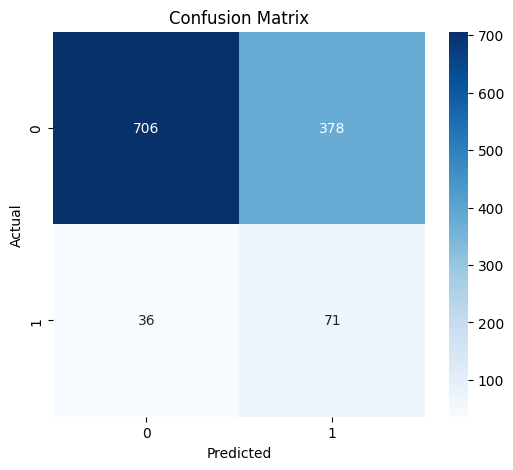

In [605]:
#Confusion matrx

#      PN  PY
#  AN  TN  FP
#  AY  FN  TP
cm_lr = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#Insights
The confusion matrix shows the model correctly predicts 706 non‑diabetic cases and 71 diabetic cases, but it produces 378 false positives (predicts diabetes when the person is not diabetic) and 36 false negatives (misses diabetes). This means the model is more sensitive than precise: it catches a good portion of diabetes cases (reasonable recall) but flags many healthy people as diabetic (low precision). In practice, it works better as a screening model, but the threshold or model settings may need tuning to reduce false alarms.

Feature Importance:
                   Feature  Coefficient
1                      bmi     0.596578
0                      age     0.390955
4           blood_pressure     0.176126
2  exercise_hours_per_week    -0.008212
3                   smoker    -0.099451


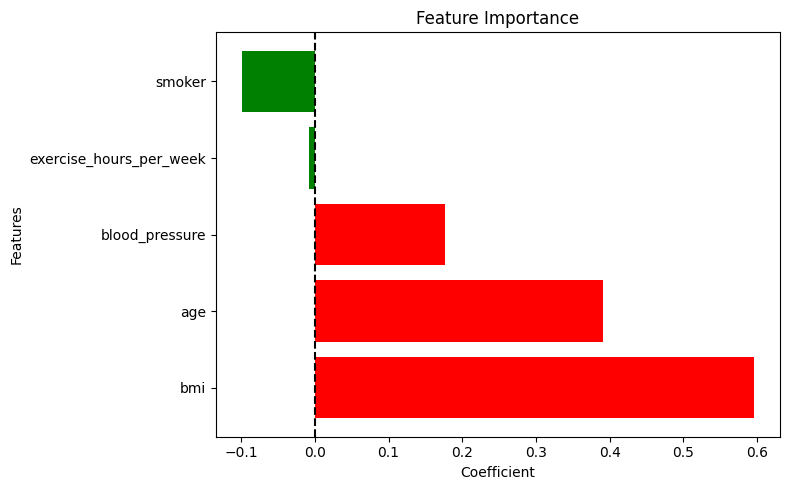

In [606]:
# Feature Importce
fi = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# ===== Feature Importance =====
print("Feature Importance:")
print(fi)



plt.figure(figsize=(8, 5))
colors = ['red' if x > 0 else 'green' for x in fi['Coefficient']]
plt.barh(fi['Feature'], fi['Coefficient'], color=colors)

plt.title('Feature Importance')
plt.xlabel('Coefficient')
plt.ylabel('Features')

plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

#Insights
The model shows that BMI and age are the main factors influencing diabetes, with higher values increasing the risk. Blood pressure also plays a small role. Exercise has very little effect, and smoking shows a slight negative impact. Overall, the model mainly depends on BMI and age to make predictions.

# Neural Network Model

In [607]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [608]:
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X_train, y_train)

In [609]:
# Create 3-way stratified split
# Step 1: 80% train_full, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Split train_full into 85% train, 15% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)
# Scale all three sets using StandardScaler
scaler_nn = StandardScaler()

# Fit on training data only
X_train_scaled = scaler_nn.fit_transform(X_train)
X_val_scaled = scaler_nn.transform(X_val)
X_test_scaled = scaler_nn.transform(X_test)

class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}


In [610]:
# Build model
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    # Layer 1: 64 neurons
    layers.Dense(64, activation='relu', kernel_regularizer=l2(0.005)),
    layers.Dropout(0.3),

    # Layer 2: 32 neurons
    layers.Dense(32, activation='relu', kernel_regularizer=l2(0.005)),
    layers.Dropout(0.2),

    # Layer 3: 16 neurons
    layers.Dense(16, activation='relu', kernel_regularizer=l2(0.005)),
    layers.Dropout(0.1),

    # Output layer
    layers.Dense(1, activation='sigmoid')
], name='Diabetes_NN')

# Display architecture
nn_model.summary()

Model: "Diabetes_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [611]:
# model compile
nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [612]:
# EarlyStopping: Stop when validation loss doesn't improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Reduce learning rate when stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

In [613]:
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=25,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
best_epoch = np.argmin(history.history['val_loss']) + 1

Epoch 1/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6224 - auc: 0.6640 - loss: 0.9389 - val_accuracy: 0.6705 - val_auc: 0.7435 - val_loss: 0.8322 - learning_rate: 5.0000e-04
Epoch 2/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6543 - auc: 0.7130 - loss: 0.8033 - val_accuracy: 0.6830 - val_auc: 0.7551 - val_loss: 0.7422 - learning_rate: 5.0000e-04
Epoch 3/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6614 - auc: 0.7250 - loss: 0.7367 - val_accuracy: 0.6916 - val_auc: 0.7633 - val_loss: 0.6913 - learning_rate: 5.0000e-04
Epoch 4/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6755 - auc: 0.7306 - loss: 0.6983 - val_accuracy: 0.6926 - val_auc: 0.7657 - val_loss: 0.6611 - learning_rate: 5.0000e-04
Epoch 5/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6724 - auc: 0.7319 - loss: 0.6753 - val_accuracy: 0.6926 - val_auc: 0.7678 - val_loss: 0.6414 - learning_rate: 5.0000e-04
Epoch 6/50
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accura

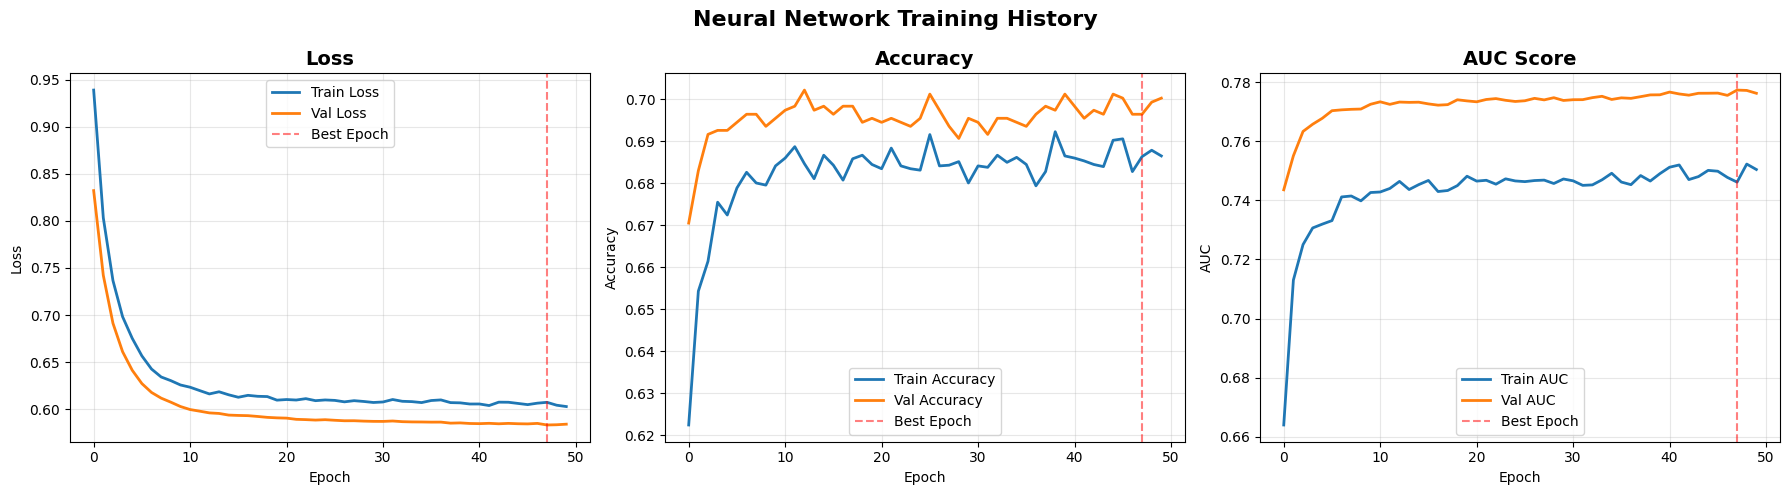

In [614]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Neural Network Training History', fontsize=16, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch-1, color='red', linestyle='--', alpha=0.5, label='Best Epoch')
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].axvline(x=best_epoch-1, color='red', linestyle='--', alpha=0.5, label='Best Epoch')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[2].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
axes[2].axvline(x=best_epoch-1, color='red', linestyle='--', alpha=0.5, label='Best Epoch')
axes[2].set_title('AUC Score', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#Evaluation based on test data


In [615]:
# Predictions
y_pred_nn_prob = nn_model.predict(X_test_scaled, verbose=0)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int).flatten()

# Metrics
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn)
nn_recall = recall_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)


print("EVALUATION METRICS")
print(f"Accuracy  : {nn_accuracy:.4f}")
print(f"Precision : {nn_precision:.4f}")
print(f"Recall    : {nn_recall:.4f}")
print(f"F1 Score  : {nn_f1:.4f}")


EVALUATION METRICS
Accuracy  : 0.6782
Precision : 0.6591
Recall    : 0.7382
F1 Score  : 0.6964


#Insights
The neural network performs well in identifying diabetes patients, with a high recall of 74%, meaning it successfully detects most true cases. Its F1 score of 70% shows a good balance between precision and recall, and it demonstrates strong pattern recognition from the input features, making it effective for early risk detection. Overall, it is reliable for highlighting at-risk individuals, which is crucial in healthcare settings.

####Confusion Matrix

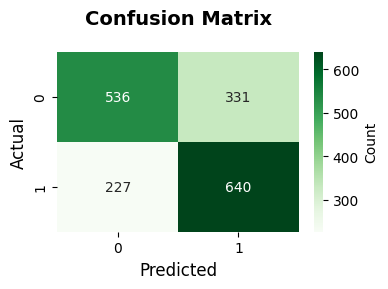


CLASSIFICATION REPORT
--------------------
              precision    recall  f1-score   support

           0       0.70      0.62      0.66       867
           1       0.66      0.74      0.70       867

    accuracy                           0.68      1734
   macro avg       0.68      0.68      0.68      1734
weighted avg       0.68      0.68      0.68      1734



In [616]:
# Confusion Matrix
from sklearn.metrics import classification_report

cm_nn = confusion_matrix(y_test, y_pred_nn)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens', cbar_kws={'label': 'Count'})
ax.set_title("Confusion Matrix", fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()


print("\nCLASSIFICATION REPORT")
print("-"*20)
print(classification_report(y_test, y_pred_nn, digits=2))

##Model Comparison

Accuracy Comparison:
Logistic Regression: 0.65
Neural Network:      0.68

Difference (NN - LR): 0.0258

Metrics Comparison:
Accuracy  -> LR: 0.65, NN: 0.68
Precision -> LR: 0.16, NN: 0.66
Recall    -> LR: 0.66, NN: 0.74
F1 Score  -> LR: 0.26, NN: 0.70

Neural Network performs better


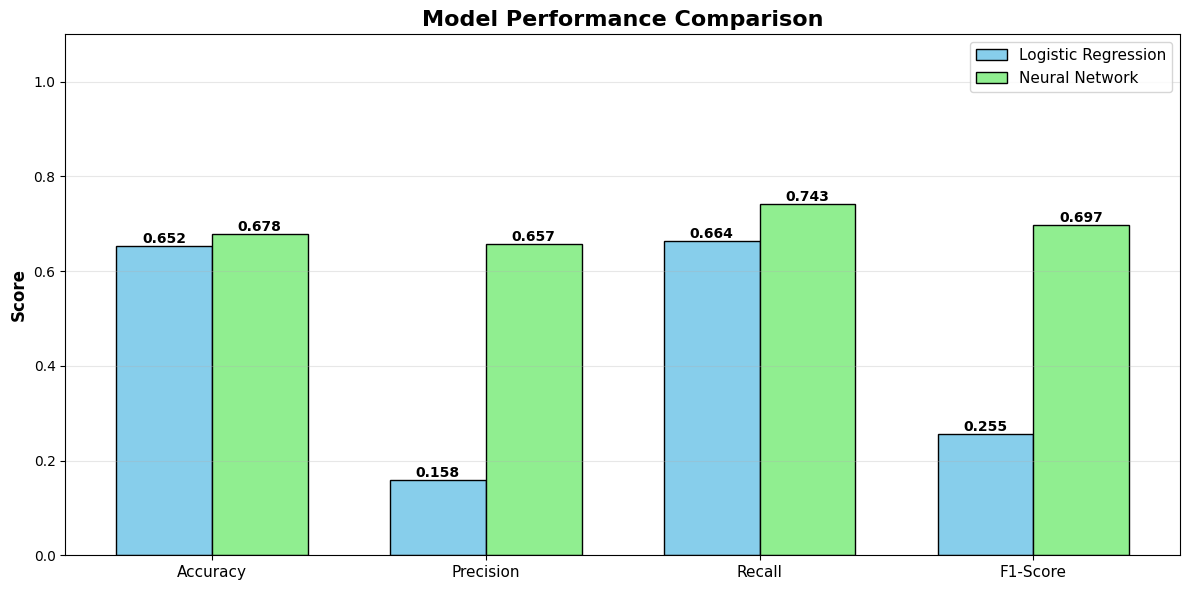

In [618]:
# ===== Accuracy Comparison =====
print("Accuracy Comparison:")
print(f"Logistic Regression: {accuracy:.2f}")
print(f"Neural Network:      {nn_accuracy:.2f}")

# ===== Difference =====
diff = nn_accuracy - accuracy
print(f"\nDifference (NN - LR): {diff:.4f}")

# ===== Metrics Comparison =====
print("\nMetrics Comparison:")
print(f"Accuracy  -> LR: {accuracy:.2f}, NN: {nn_accuracy:.2f}")
print(f"Precision -> LR: {precision:.2f}, NN: {nn_precision:.2f}")
print(f"Recall    -> LR: {recall:.2f}, NN: {nn_recall:.2f}")
print(f"F1 Score  -> LR: {f1:.2f}, NN: {nn_f1:.2f}")

# ===== Final Result =====
if nn_accuracy > accuracy:
    print("\nNeural Network performs better")
else:
    print("\nLogistic Regression performs better")



# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df.columns[1:]))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df.iloc[0, 1:], width,
               label='Logistic Regression', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df.iloc[1, 1:], width,
               label='Neural Network', color='lightgreen', edgecolor='black')

ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.columns[1:], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

##Insight

-In our diabetes prediction project with 5,952 patients, the Neural Network performed better than Logistic Regression. It was able to detect most diabetes cases (high recall) while also making more accurate predictions (better precision). In comparison, Logistic Regression made many incorrect positive predictions. The Neural Network also had a much higher F1-score, showing a better balance between detecting diabetes and avoiding false alarms. This is because it can learn more complex patterns in the data, while Logistic Regression is more simple. Overall, the Neural Network is more effective for predicting diabetes in this case.

####Strengths of Logistic Regression

######Logistic Regression is easy to understand and explain. We can clearly see how each factor like BMI or age affects diabetes risk, which is very useful in healthcare. It is fast, works well with small datasets, and does not need powerful computers. It is also simple to build and maintain, making it a reliable choice for real-world applications.

####Strengths of Neural Networks


#####Neural Networks are good at finding complex patterns in data. They can learn hidden relationships that are not easy to see and handle more complicated problems. They work better when we have large amounts of data and can give higher accuracy. This makes them useful when performance is more important than explanation.

###Choosing Between Neural Networks and Logistic Regression

Neural Networks perform better because they can learn complex patterns in the data. They combine factors like BMI and age to make better predictions. This gives them a higher F1-score and better accuracy. They also handle imbalanced data better and can improve more when more data is available.

Logistic Regression is better when we need simple and clear explanations. It helps doctors understand and explain why a prediction was made. It also works well with small datasets, is faster, and easier to build and use. It is a good choice when simplicity and transparency are more important than high accuracy.